In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

Using notebook 3d backend.


In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep'
        ]


ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='LBA',
            suffix='zscore',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'

HGAs.head()

100%|██████████| 721/721 [02:11<00:00,  5.49it/s]


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0019_ROG1-2,-0.029893,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,20.731562,-95.433053,-4.406237
1,-1.0,D0019_ROG2-3,-0.106969,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,18.712896,-94.417750,6.523434
2,-1.0,D0019_ROG4-5,-0.005561,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_occipital_sup,sOccG,R,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG6-7,-0.047000,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,21.415317,-87.142845,15.405992
4,-1.0,D0019_ROG7-8,-0.148092,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,31.738807,-94.023646,-5.934703


In [4]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0040_L1IF2-3', 'D0040_L1IF3-4', 'D0079_LFAI1-2', 'D0079_LFAI2-3', 'D0079_LFMI1-2', 'D0079_LPI9-10', 'D0103_LAI7-8', 'D0103_LAI3-4', 'D0103_LAI5-6', 'D0103_LAI6-7']


In [5]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 387776
PIC electrode count: 450432


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0019_ROG1-2,-0.029893,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,20.731562,-95.433053,-4.406237
1,-1.0,D0019_ROG2-3,-0.106969,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,18.712896,-94.417750,6.523434
2,-1.0,D0019_ROG4-5,-0.005561,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_occipital_sup,sOccG,R,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG6-7,-0.047000,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,21.415317,-87.142845,15.405992
4,-1.0,D0019_ROG7-8,-0.148092,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,31.738807,-94.023646,-5.934703


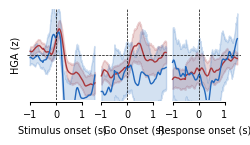

In [6]:
rois = ['AIC']
colors = [red, blue]

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality=='sound')
    & (HGAs.hemi=='L')
    & (HGAs.subject!='D0121')
    & (HGAs.roi.isin(rois) | HGAs.label.str.contains('Opercular'))
]

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(7*cm, 3*cm),gridspec_kw={'width_ratios': [2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
line1 = sns.lineplot(
    data=subset[(subset.phase == 'stimulus')],
    x='time',
    y='value',
    hue='roi',
    hue_order=['AIC', 'IFG'],
    ax=ax1,
    palette=colors,
    legend=False,
    lw=1
)

line3 = sns.lineplot(
    data=subset[(subset.phase == 'go')],
    x='time',
    y='value',
    hue='roi',
    hue_order=['AIC', 'IFG'],
    ax=ax2,
    palette=colors,
    legend=False,
    lw=1
)

line4 = sns.lineplot(
    data=subset[(subset.phase == 'response')],
    x='time',
    y='value',
    hue='roi',
    hue_order=['AIC', 'IFG'],
    ax=ax3,
    palette=colors,
    legend=True,
    lw=1
)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax == ax2 and ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.2, 0.2)
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Go Onset (s)', fontsize=7)   
ax3.set_xlabel('Response onset (s)', fontsize=7)   

ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)
# plt.savefig('../img/fig2/fig2_AIPI_temporal_LS.svg', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# drop columns
cords = HGAs.copy().drop(columns=["time","value"]).drop_duplicates()
cords.head()

,channel,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,D0019_ROG1-2,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,20.731562,-95.433053,-4.406237
1,D0019_ROG2-3,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,18.712896,-94.417750,6.523434
2,D0019_ROG4-5,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_occipital_sup,sOccG,R,16.298644,-91.860079,29.446276
3,D0019_ROG6-7,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,21.415317,-87.142845,15.405992
4,D0019_ROG7-8,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,31.738807,-94.023646,-5.934703


In [ ]:
pick = cords[(cords.roi=='AIC') | (cords.label.str.contains('Opercular')) & (cords.hemi=='L')]

# Find subjects that have both IFG and AIC
subjects_with_both = pick.groupby('subject')['roi'].apply(lambda x: set(x) >= {'IFG', 'AIC'})
subjects_with_both = subjects_with_both[subjects_with_both].index.tolist()

# Filter data for subjects with both ROIs
filtered_data = pick[pick.subject.isin(subjects_with_both)]

# Create MultiIndex DataFrame with each electrode as separate row
electrode_df = filtered_data.set_index(['subject', 'roi']).sort_index()

# Display the MultiIndex DataFrame
electrode_df

channel   mask description           task  phase modality  \
subject roi                                                                    
D0032   AIC   D0032_LAI1-2  False    Decision   LexicalDelay  delay    sound   
        AIC   D0032_LAI3-4  False    Decision   LexicalDelay  delay    sound   
        AIC   D0032_LAI4-5  False    Decision   LexicalDelay  delay    sound   
        AIC   D0032_LAI1-2  False      Repeat   LexicalDelay  delay    sound   
        AIC   D0032_LAI3-4  False      Repeat   LexicalDelay  delay    sound   
...                    ...    ...         ...            ...    ...      ...   
D0106   IFG  D0106_LTAS4-5   True     Passive  PictureNaming     go     text   
        IFG  D0106_LTAS4-5  False     Passive  PictureNaming     go     text   
        IFG  D0106_LTAS3-4  False      Repeat  PictureNaming     go     text   
        IFG  D0106_LTAS4-5  False      Repeat  PictureNaming     go     text   
        IFG  D0106_LTAS4-5   True      Repeat  PictureNaming     go     text   

                                    label hemi          x          y         z  
subject roi                                                                     
D0032   AIC        ctx_lh_G_insular_short    L -37.007849   9.260216 -8.201160  
        AIC        ctx_lh_G_insular_short    L -37.042906  10.072254 -0.909710  
        AIC  ctx_lh_S_circular_insula_sup    L -37.060344  10.755693  2.733611  
        AIC        ctx_lh_G_insular_short    L -37.007849   9.260216 -8.201160  
        AIC        ctx_lh_G_insular_short    L -37.042906  10.072254 -0.909710  
...                                   ...  ...        ...        ...       ...  
D0106   IFG  ctx_lh_G_front_inf-Opercular    L -52.173326   4.333749 -8.364291  
        IFG  ctx_lh_G_front_inf-Opercular    L -52.173326   4.333749 -8.364291  
        IFG  ctx_lh_G_front_inf-Opercular    L -47.882854   5.629037 -7.528778  
        IFG  ctx_lh_G_front_inf-Opercular    L -52.173326   4.333749 -8.364291  
        IFG  ctx_lh_G_front_inf-Opercular    L -52.173326   4.333749 -8.364291  

[554 rows x 11 columns]

In [34]:
filtered_data.subject.unique()

array(['D0035', 'D0040', 'D0067', 'D0094', 'D0096', 'D0032', 'D0106'],
      dtype=object)

In [144]:
# load raw data
LEXICAL_DELAY_PT = '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/'
PHONEME_PT = '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/'


sub = 'D0040'
# Get channels for AIC and IFG separately
aic_chns = electrode_df.loc[(sub, 'AIC'), 'channel'].unique().tolist()
ifg_chns = electrode_df.loc[(sub, 'IFG'), 'channel'].unique().tolist()

pick_chns = aic_chns + ifg_chns

raw_pt = BIDSPath(
    root=os.path.join(PHONEME_PT, 'derivatives', 'epoch(bipolar)'),
    datatype='epoch(band)(power)',
    subject=sub,
    suffix='highgamma',
    processing='Response',
    extension='.h5',
    check=False
)
raw_pt = raw_pt.match()[0]
raw_epo = mne.read_epochs(raw_pt, preload=True, verbose='error')  # 改为 preload=True
raw_epo = raw_epo.pick_channels(pick_chns, verbose='error')
raw_epo = raw_epo.crop(tmin=None, tmax=0)
# raw_epo = raw_epo.average()

In [145]:
df = raw_epo.to_data_frame(long_format=True)
df['roi'] = ' '
df.loc[df.channel.isin(aic_chns), 'roi'] = 'AIC'
df.loc[df.channel.isin(ifg_chns), 'roi'] = 'IFG'
df.head()

Converting "condition" to "category"...
Converting "epoch" to "category"...
Converting "channel" to "category"...
Converting "ch_type" to "category"...


,condition,epoch,time,channel,ch_type,value,roi
0,Word/Response/LS/kub,9,-1.000000,D0040_L2IF4-5,seeg,0.004395,AIC
1,Word/Response/LS/kub,9,-1.000000,D0040_L3IF3-4,seeg,0.007199,IFG
2,Word/Response/LS/kub,9,-1.000000,D0040_L3IF5-6,seeg,0.008513,IFG
3,Word/Response/LS/kub,9,-1.000000,D0040_L1SF5-6,seeg,0.006687,IFG
4,Word/Response/LS/kub,9,-0.992188,D0040_L2IF4-5,seeg,0.004093,AIC


In [146]:
# Compute AIC×IFG cross-correlation on raw (non-averaged) epochs
import numpy as np
from scipy.signal import correlate

# 1) Reload raw epochs WITHOUT averaging/cropping
raw_epo_full = mne.read_epochs(raw_pt, preload=True, verbose='error')
raw_epo_full = raw_epo_full.pick_channels(pick_chns, verbose='error')

# 2) Helper: z-scored cross-correlation (amplitude-invariant)
# Returns: xcorr shape (n_epochs, n_aic, n_ifg, n_lags), lag_times (seconds)
def compute_aic_ifg_xcorr_z(epochs, aic_chns, ifg_chns, max_lag_seconds=1.0):
    sfreq = epochs.info['sfreq']
    max_lag = int(round(max_lag_seconds * sfreq)) if max_lag_seconds is not None else None

    # data shapes: (n_epochs, n_chan, n_times)
    data_aic = epochs.get_data(picks=aic_chns)
    data_ifg = epochs.get_data(picks=ifg_chns)
    n_epo, n_aic, n_t = data_aic.shape
    _, n_ifg, _ = data_ifg.shape

    # z-score per epoch per channel (remove mean, divide by std)
    def zscore(x, axis=-1):
        m = x.mean(axis=axis, keepdims=True)
        s = x.std(axis=axis, keepdims=True)
        s[s == 0] = 1.0  # avoid division by zero
        return (x - m) / s

    data_aic_z = zscore(data_aic)
    data_ifg_z = zscore(data_ifg)

    # lag grid
    full_lags = np.arange(-n_t + 1, n_t)
    if max_lag is not None:
        keep = (full_lags >= -max_lag) & (full_lags <= max_lag)
    else:
        keep = slice(None)
    lags = full_lags[keep]
    lag_times = lags / sfreq

    # allocate
    xcorr = np.empty((n_epo, n_aic, n_ifg, lags.size), dtype=np.float64)

    # correlate z-scored signals; normalize by length to get Pearson-like scale
    norm = n_t  # optional: use np.sqrt(np.sum(x^2) * np.sum(y^2)) if you change padding
    for e in range(n_epo):
        for i in range(n_aic):
            for j in range(n_ifg):  
                c = correlate(data_aic_z[e, i], data_ifg_z[e, j], mode='full', method='auto')
                sign = np.sign(c[np.argmax(np.abs(c))])
                xcorr[e, i, j] = c[keep] / norm * sign
    return xcorr, lag_times

# Example: lag window ±1 s, z-scored (amplitude-invariant)
xcorr, lag_times = compute_aic_ifg_xcorr_z(raw_epo_full, aic_chns, ifg_chns, max_lag_seconds=1.0)
print('xcorr shape:', xcorr.shape)  # (n_epochs, n_aic, n_ifg, n_lags)
print('lag_times (s) range:', lag_times[0], 'to', lag_times[-1])

# square to convert to variance explained
xcorr = xcorr**2
xcorr = xcorr.mean(axis=0)  # if you want AIC×IFG×lag averaged across epochs

xcorr shape: (172, 1, 3, 257)
lag_times (s) range: -1.0 to 1.0


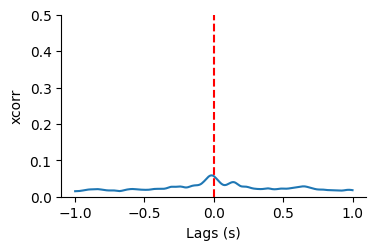

In [155]:
i = 0
j = 0

fig, ax = plt.subplots(figsize=(10*cm, 6*cm))
plt.plot(lag_times,xcorr[i,j])

vmin, vmax = np.percentile(xcorr, (1, 99))
ax.set_ylim(0, 0.5)
sns.despine()
ax.set_xlabel('Lags (s)')
ax.set_ylabel('xcorr')

ax.axvline(x=0, color='r', linestyle='--')

<Axes: xlabel='time', ylabel='value'>

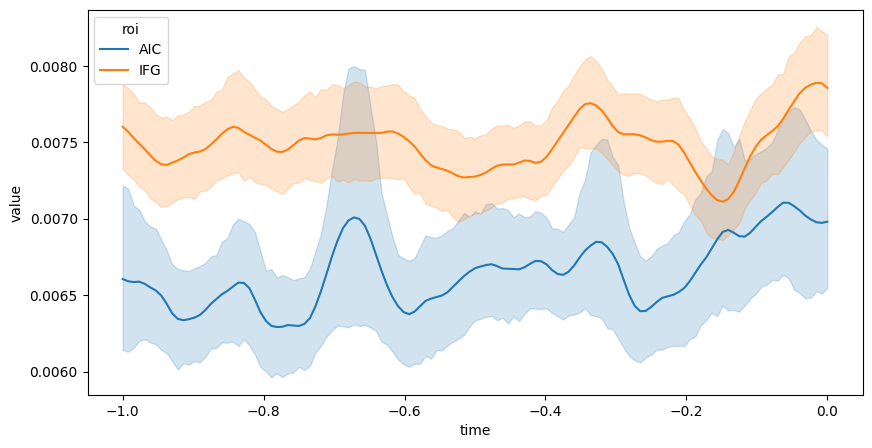

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.lineplot(data=df, x='time', y='value', hue='roi', ax=ax)

# Load xcorr results

In [15]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep'
        ]

ref = 'bipolar'
xcorr_paths = []
for t in task:
    xcorr_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='xcorr',
            suffix='highgamma',
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
xcorrs = []
for path in tqdm(xcorr_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    xcorrs.append(df)

xcorrs = pd.concat(xcorrs)

# rename INS to 'Insula'
xcorrs.head()

100%|██████████| 796/796 [03:13<00:00,  4.11it/s]


,trial,source,target,source_roi,source_label,source_x,source_y,source_z,target_roi,target_label,target_x,target_y,target_z,peak_val,peak_lag_s,subject,phase,description,band,task
0,0,D0022_LPIF3-4,D0022_LMSF3-4,INS,ctx_lh_S_circular_insula_inf,-34.587586,-19.67704,-2.311079,MFG,ctx_lh_G_front_middle,-23.566958,57.766359,26.940067,0.018116,-0.2960,D0022,Go,Repeat,highgamma,PhonemeSequence
1,0,D0022_LPIF3-4,D0022_LMSF4-5,INS,ctx_lh_S_circular_insula_inf,-34.587586,-19.67704,-2.311079,MFG,ctx_lh_G_front_middle,-21.821305,53.991872,33.249195,0.013000,-0.4465,D0022,Go,Repeat,highgamma,PhonemeSequence
2,0,D0022_LPIF3-4,D0022_LAMF5-6,INS,ctx_lh_S_circular_insula_inf,-34.587586,-19.67704,-2.311079,MFG,ctx_lh_G_front_middle,-39.572375,31.169603,29.362010,0.014330,0.9775,D0022,Go,Repeat,highgamma,PhonemeSequence
3,0,D0022_LPIF3-4,D0022_LMIF2-3,INS,ctx_lh_S_circular_insula_inf,-34.587586,-19.67704,-2.311079,Put,Left-Putamen,-30.945483,-15.142778,-10.141665,0.015048,-0.5535,D0022,Go,Repeat,highgamma,PhonemeSequence
4,0,D0022_LPIF3-4,D0022_LMIF5-6,INS,ctx_lh_S_circular_insula_inf,-34.587586,-19.67704,-2.311079,HG,ctx_lh_S_temporal_transverse,-49.716957,-12.270617,-12.142812,0.017680,0.0680,D0022,Go,Repeat,highgamma,PhonemeSequence


In [16]:
xcorrs[xcorrs.target_roi=='IFG'].target_label.unique()

array(['ctx_lh_G_front_inf-Orbital', 'ctx_lh_G_front_inf-Opercular',
       'ctx_lh_G_front_inf-Triangul', 'ctx_rh_G_front_inf-Triangul',
       'ctx_rh_G_front_inf-Orbital', 'ctx_rh_G_front_inf-Opercular'],
      dtype=object)

In [17]:
oper_xcorrs = xcorrs[
                    (xcorrs.target_label.str.contains('Opercular')) 
                     & (xcorrs.target_label.str.contains('lh'))
                     & (xcorrs.source_label.str.contains('insular_short'))]

# oper_xcorrs = xcorrs[(xcorrs.target_roi.str.contains('PrG')) 
#                      & (xcorrs.target_label.str.contains('lh'))
#                      & (xcorrs.source_label.str.contains('insular_short'))]
oper_xcorrs.head()

,trial,source,target,source_roi,source_label,source_x,source_y,source_z,target_roi,target_label,target_x,target_y,target_z,peak_val,peak_lag_s,subject,phase,description,band,task
13,0,D0035_LAI1-2,D0035_LAI4-5,INS,ctx_lh_G_insular_short,-39.677537,8.522433,-4.664427,IFG,ctx_lh_G_front_inf-Opercular,-38.210179,9.940248,8.153676,0.010730,0.542480,D0035,Go,Repeat,highgamma,PhonemeSequence
34,0,D0035_LAI2-3,D0035_LAI4-5,INS,ctx_lh_G_insular_short,-39.738028,8.655055,-0.744315,IFG,ctx_lh_G_front_inf-Opercular,-38.210179,9.940248,8.153676,0.019864,-0.000488,D0035,Go,Repeat,highgamma,PhonemeSequence
97,1,D0035_LAI1-2,D0035_LAI4-5,INS,ctx_lh_G_insular_short,-39.677537,8.522433,-4.664427,IFG,ctx_lh_G_front_inf-Opercular,-38.210179,9.940248,8.153676,0.011708,0.475586,D0035,Go,Repeat,highgamma,PhonemeSequence
118,1,D0035_LAI2-3,D0035_LAI4-5,INS,ctx_lh_G_insular_short,-39.738028,8.655055,-0.744315,IFG,ctx_lh_G_front_inf-Opercular,-38.210179,9.940248,8.153676,0.016403,0.022949,D0035,Go,Repeat,highgamma,PhonemeSequence
181,2,D0035_LAI1-2,D0035_LAI4-5,INS,ctx_lh_G_insular_short,-39.677537,8.522433,-4.664427,IFG,ctx_lh_G_front_inf-Opercular,-38.210179,9.940248,8.153676,0.011169,-0.860840,D0035,Go,Repeat,highgamma,PhonemeSequence


In [18]:
oper_xcorrs.source.unique()

array(['D0035_LAI1-2', 'D0035_LAI2-3', 'D0094_LIA1-2', 'D0094_LIA2-3',
       'D0094_LIA3-4', 'D0032_LAI1-2', 'D0032_LAI3-4', 'D0096_LIA1-2',
       'D0096_LIA2-3', 'D0096_LIA3-4', 'D0096_LIA4-5', 'D0096_LIP3-4',
       'D0096_LIP4-5', 'D0106_LAI1-2', 'D0106_LAI2-3', 'D0106_LAI3-4',
       'D0106_LAI7-8', 'D0106_LTAS1-2', 'D0106_LTAS2-3', 'D0121_LTAS1-2',
       'D0121_LTAS2-3', 'D0121_LTAS3-4', 'D0122_LFAI3-4', 'D0122_LTAS1-2',
       'D0122_LTAS2-3', 'D0125_LIA3-4', 'D0125_LIA4-5', 'D0125_LTAS2-3',
       'D0125_LTAS3-4'], dtype=object)

In [ ]:
oper_xcorrs = oper_xcorrs[
    (~oper_xcorrs.source.isin(['D0106_LTAS2-3', 'D0125_LIA4-5',
                                'D0122_LFAI3-4', 'D0035_LAI2-3',
                                'D0125_LAI4-5', 'D0125_LAI3-4','D0125_LTAS3-4']))
]
oper_xcorrs.groupby(['subject', 'phase', 'description'])[['peak_val','peak_lag_s']].agg(['mean', 'std'])

peak_val           peak_lag_s          
                                  mean       std       mean       std
subject phase    description                                         
D0032   Delay    Decision     0.018602  0.005135  -0.030044  0.453056
                 Repeat       0.018319  0.004698   0.010745  0.451031
        Go       Decision     0.018769  0.005176  -0.009687  0.485340
                 Repeat       0.018834  0.004935   0.040719  0.449609
        Response Decision     0.018267  0.005331  -0.035896  0.470434
                 Repeat       0.019034  0.005279  -0.020393  0.465938
        Stimulus Decision     0.018535  0.005042  -0.025665  0.437721
                 Repeat       0.018294  0.005940   0.005976  0.448564
D0035   Go       Repeat       0.013335  0.003012  -0.011894  0.432788
        Response Repeat       0.013186  0.002968  -0.006950  0.440908
        Stimulus Repeat       0.013254  0.003039  -0.011359  0.462224
D0094   Delay    Decision     0.021202  0.004852  -0.019524  0.466411
                 Repeat       0.021256  0.005475  -0.062118  0.460690
        Go       Decision     0.021628  0.005432  -0.025766  0.482882
                 Passive      0.019039  0.004419   0.019535  0.474498
                 Repeat       0.021137  0.005307  -0.024385  0.466653
        Response Decision     0.020799  0.005076   0.002595  0.467367
                 Passive      0.019435  0.004614  -0.021962  0.459582
                 Repeat       0.020845  0.005177  -0.006394  0.466975
        Stimulus Decision     0.020561  0.004771  -0.022568  0.465976
                 Passive      0.019367  0.004855   0.006959  0.465100
                 Repeat       0.019888  0.004583  -0.008756  0.460382
D0096   Go       Passive      0.021302  0.005362   0.009728  0.454799
                 Repeat       0.021881  0.005443   0.009500  0.477677
        Response Repeat       0.022052  0.005577   0.025274  0.479398
        Stimulus Passive      0.021489  0.005205   0.029632  0.465251
                 Repeat       0.021593  0.005496   0.005756  0.470425
D0106   Go       Passive      0.019826  0.004676   0.017942  0.453219
                 Repeat       0.020068  0.004828  -0.026923  0.465605
        Response Repeat       0.020359  0.004894  -0.022166  0.487665
        Stimulus Passive      0.019415  0.004712  -0.009769  0.470711
                 Repeat       0.019844  0.005054  -0.015274  0.461020
D0121   Go       Passive      0.018853  0.004870  -0.037098  0.464107
                 Repeat       0.018972  0.005149  -0.008849  0.467838
        Response Repeat       0.018928  0.005096  -0.004233  0.465681
        Stimulus Passive      0.019268  0.005260   0.035440  0.455040
                 Repeat       0.018892  0.004885   0.046376  0.476347
D0122   Go       Passive      0.022336  0.006854   0.031428  0.494666
                 Repeat       0.024256  0.006894  -0.073505  0.499978
        Response Repeat       0.023983  0.006955  -0.069980  0.500651
        Stimulus Passive      0.022344  0.006956  -0.028378  0.487306
                 Repeat       0.022827  0.006980  -0.020698  0.478111
D0125   Go       Passive      0.024818  0.010316  -0.003913  0.405328
                 Repeat       0.024176  0.007771   0.012277  0.427200
        Response Repeat       0.024217  0.007842  -0.001796  0.426263
        Stimulus Passive      0.024271  0.009305  -0.019620  0.421450
                 Repeat       0.024096  0.008115   0.017687  0.417698

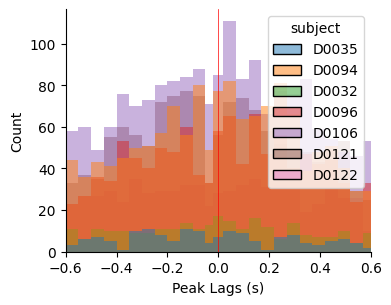

In [20]:
fig,ax = plt.subplots(1,1, figsize=(10*cm, 8*cm))

# sns.histplot(
#     oper_xcorrs[(oper_xcorrs.description=='Repeat') & (oper_xcorrs.phase=='Response')],
#     x='peak_lag_s',
#     hue='subject',
#     binwidth=0.05,
#     ax=ax,
# )

center = 0.02  # 2 ms (seconds)
edges = np.r_[
    np.arange(-0.6, -center, 0.05),
    -center, center,
    np.arange(center, 0.6 + 0.05, 0.05),
]

sns.histplot(data=oper_xcorrs[(oper_xcorrs.description=='Repeat') 
                              & (oper_xcorrs.phase=='Response')
                              & (oper_xcorrs.subject!='D0125')
                              & (~oper_xcorrs.source.isin(['D0106_LTAS2-3', 'D0125_LIA4-5',
                                                           'D0122_LFAI3-4', 'D0035_LAI2-3',
                                                           'D0125_LAI4-5', 'D0125_LAI3-4','D0125_LTAS3-4']))], 
             x="peak_lag_s", 
             hue="subject", bins=edges, ax=ax)

ax.set_xlim(-0.6, 0.6)
ax.set_xlabel('Peak Lags (s)')
sns.despine()
ax.axvline(x=0., color='r', lw=0.5)
# ax.set_xlim(0, 0.5)

In [21]:
oper_xcorrs[(oper_xcorrs.description=='Repeat') & (oper_xcorrs.phase=='Response')
                              & (oper_xcorrs.subject=='D0125')].source.unique()

array(['D0125_LIA3-4', 'D0125_LTAS2-3'], dtype=object)

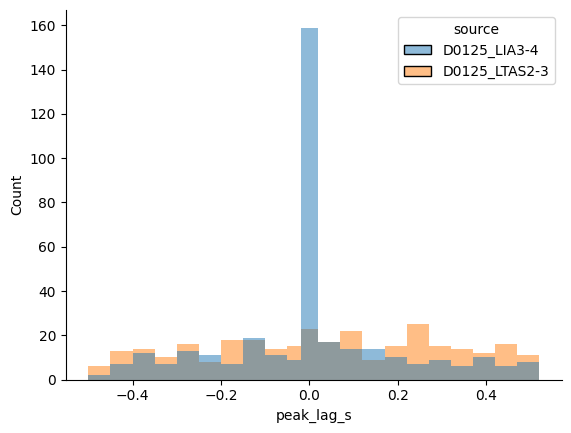

In [22]:
edges = np.r_[
    np.arange(-0.5, -center, 0.05),
    -center, center,
    np.arange(center, 0.5 + 0.05, 0.05),
]

sns.histplot(data=oper_xcorrs[(oper_xcorrs.description=='Repeat') & (oper_xcorrs.phase=='Response')
                              & (oper_xcorrs.subject=='D0125')], 
             x="peak_lag_s", 
             hue="source", bins=edges)

sns.despine()

In [23]:
oper_xcorrs[(oper_xcorrs.description=='Repeat') & (oper_xcorrs.phase=='Stimulus')
                              & (oper_xcorrs.subject=='D0106')]

,trial,source,target,source_roi,source_label,source_x,source_y,source_z,target_roi,target_label,target_x,target_y,target_z,peak_val,peak_lag_s,subject,phase,description,band,task
11,0,D0106_LAI1-2,D0106_LTAS3-4,INS,ctx_lh_G_insular_short,-33.921272,12.127291,-24.181028,IFG,ctx_lh_G_front_inf-Opercular,-47.882854,5.629037,-7.528778,0.016834,-0.345703,D0106,Stimulus,Repeat,highgamma,PictureNaming
12,0,D0106_LAI1-2,D0106_LTAS4-5,INS,ctx_lh_G_insular_short,-33.921272,12.127291,-24.181028,IFG,ctx_lh_G_front_inf-Opercular,-52.173326,4.333749,-8.364291,0.022845,-0.326172,D0106,Stimulus,Repeat,highgamma,PictureNaming
29,0,D0106_LAI2-3,D0106_LTAS3-4,INS,ctx_lh_G_insular_short,-33.563091,14.225522,-20.688729,IFG,ctx_lh_G_front_inf-Opercular,-47.882854,5.629037,-7.528778,0.016372,0.531738,D0106,Stimulus,Repeat,highgamma,PictureNaming
30,0,D0106_LAI2-3,D0106_LTAS4-5,INS,ctx_lh_G_insular_short,-33.563091,14.225522,-20.688729,IFG,ctx_lh_G_front_inf-Opercular,-52.173326,4.333749,-8.364291,0.017750,-0.272461,D0106,Stimulus,Repeat,highgamma,PictureNaming
47,0,D0106_LAI3-4,D0106_LTAS3-4,INS,ctx_lh_G_insular_short,-33.183625,16.435040,-16.995012,IFG,ctx_lh_G_front_inf-Opercular,-47.882854,5.629037,-7.528778,0.012075,-0.772949,D0106,Stimulus,Repeat,highgamma,PictureNaming
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14268,79,D0106_LAI3-4,D0106_LTAS4-5,INS,ctx_lh_G_insular_short,-33.183625,16.435040,-16.995012,IFG,ctx_lh_G_front_inf-Opercular,-52.173326,4.333749,-8.364291,0.022400,0.289551,D0106,Stimulus,Repeat,highgamma,PictureNaming
14285,79,D0106_LAI7-8,D0106_LTAS3-4,INS,ctx_lh_G_insular_short,-31.580150,25.718391,-1.414454,IFG,ctx_lh_G_front_inf-Opercular,-47.882854,5.629037,-7.528778,0.015337,-0.052734,D0106,Stimulus,Repeat,highgamma,PictureNaming
14286,79,D0106_LAI7-8,D0106_LTAS4-5,INS,ctx_lh_G_insular_short,-31.580150,25.718391,-1.414454,IFG,ctx_lh_G_front_inf-Opercular,-52.173326,4.333749,-8.364291,0.016149,-0.734375,D0106,Stimulus,Repeat,highgamma,PictureNaming
14339,79,D0106_LTAS1-2,D0106_LTAS3-4,INS,ctx_lh_G_insular_short,-39.301917,8.219612,-5.857753,IFG,ctx_lh_G_front_inf-Opercular,-47.882854,5.629037,-7.528778,0.016538,0.577637,D0106,Stimulus,Repeat,highgamma,PictureNaming
